# Quarterly VAR: Scenario-Conditional Loan Forecasting

**Purpose:** Re-estimate the scenario forecasting pipeline at **quarterly frequency** to compare with the annual model.

**Why quarterly?**
- Annual model has only 35 observations for 4-5 variable VARs — thin for reliable inference
- Quarterly gives ~140 observations — ~4x statistical power
- BofA said: "Try different frequencies and see what makes your model perform the best"
- Key question: does unemployment become significant for consumer loans at quarterly frequency?

**NGFS handling:** NGFS scenarios are annual. We interpolate to quarterly using linear interpolation (smooth within-year transition).

**Structure mirrors `scenario_forecasting.ipynb` so results are directly comparable.**

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

SCENARIO_COLORS = {
    'Net Zero 2050': '#1b9e77',
    'Below 2\u00b0C': '#66a61e',
    'Delayed transition': '#d95f02',
    'Nationally Determined Contributions (NDCs)': '#e7298a',
    'Fragmented World': '#a6761d',
    'Current Policies': '#e6ab02',
    'Baseline': '#666666',
}

KEY_SCENARIOS = ['Net Zero 2050', 'Delayed transition',
                 'Nationally Determined Contributions (NDCs)']
KEY_SCENARIO_SHORT = {'Net Zero 2050': 'Net Zero',
                      'Delayed transition': 'Delayed Trans.',
                      'Nationally Determined Contributions (NDCs)': 'NDCs'}

print('Setup complete.')

Setup complete.


In [2]:
# Load FRED series
series_info = {
    'BUSLOANS':  ('C&I Loans (Billions $)', 'M'),
    'CONSUMER':  ('Consumer Loans (Billions $)', 'M'),
    'GDPC1':     ('Real GDP (Billions 2017$)', 'Q'),
    'UNRATE':    ('Unemployment Rate (%)', 'M'),
    'FEDFUNDS':  ('Fed Funds Rate (%)', 'M'),
    'DGS10':     ('10-Year Treasury Yield (%)', 'M'),
    'CPIAUCSL':  ('CPI (Index)', 'M'),
}

fred = {}
for ticker, (label, freq) in series_info.items():
    df = pd.read_csv(f'{DATA_DIR}{ticker}.csv', parse_dates=['date'], index_col='date')
    df.columns = [ticker]
    df = df.replace('.', np.nan).dropna()
    df[ticker] = df[ticker].astype(float)
    fred[ticker] = df
    print(f'{ticker:12s} | {label:35s} | {df.index[0].date()} to {df.index[-1].date()} | n={len(df):>5d} | {freq}')

BUSLOANS     | C&I Loans (Billions $)              | 1947-01-01 to 2025-12-01 | n=  948 | M
CONSUMER     | Consumer Loans (Billions $)         | 1947-01-01 to 2025-12-01 | n=  948 | M
GDPC1        | Real GDP (Billions 2017$)           | 1947-01-01 to 2025-07-01 | n=  315 | Q
UNRATE       | Unemployment Rate (%)               | 1948-01-01 to 2026-01-01 | n=  936 | M
FEDFUNDS     | Fed Funds Rate (%)                  | 1954-07-01 to 2026-01-01 | n=  859 | M
DGS10        | 10-Year Treasury Yield (%)          | 1962-01-02 to 2026-02-11 | n=16012 | M
CPIAUCSL     | CPI (Index)                         | 1947-01-01 to 2026-01-01 | n=  948 | M


In [3]:
# Load NGFS NiGEM data
nigem_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-nigem.xlsx', sheet_name='data')
nigem_us = nigem_raw[nigem_raw['Region'] == 'NiGEM NGFS v1.24.2|United States'].copy()
nigem_us = nigem_us.drop_duplicates(subset=['Model', 'Scenario', 'Variable'])

year_cols = [c for c in nigem_us.columns if isinstance(c, str) and c.isdigit()]
years = [int(y) for y in year_cols]

MODELS = sorted(nigem_us['Model'].unique())
MODEL_SHORT = {m: m.split('[')[1].rstrip(']') if '[' in m else m for m in MODELS}

print(f'NiGEM U.S. rows: {len(nigem_us)}')
print(f'Models: {list(MODEL_SHORT.values())}')

NiGEM U.S. rows: 1824
Models: ['GCAM 6.0 NGFS', 'MESSAGEix-GLOBIOM 2.0-M-R12-NGFS', 'REMIND-MAgPIE 3.3-4.8']


## 2. Quarterly Data Preparation

In [4]:
# --- Monthly transformations (same as annual notebook) ---
monthly = pd.DataFrame(index=fred['BUSLOANS'].index)

for ticker in ['BUSLOANS', 'CONSUMER', 'CPIAUCSL']:
    monthly[f'{ticker}_g'] = 100 * np.log(fred[ticker][ticker] / fred[ticker][ticker].shift(1))

gdp_m = fred['GDPC1'].resample('MS').ffill()
monthly['GDPC1_g'] = 100 * np.log(gdp_m['GDPC1'] / gdp_m['GDPC1'].shift(1))

# First differences for rate/percentage variables
# UNRATE and FEDFUNDS are already monthly
for ticker in ['UNRATE', 'FEDFUNDS']:
    monthly[f'{ticker}_chg'] = fred[ticker][ticker].diff()

# DGS10 is DAILY — must aggregate to monthly first, then difference
dgs10_monthly = fred['DGS10'].resample('MS').last()  # last trading day of month
monthly['DGS10_chg'] = dgs10_monthly['DGS10'].diff()

monthly['COVID'] = ((monthly.index >= '2020-03-01') & (monthly.index <= '2021-06-01')).astype(int)
monthly = monthly.dropna()

# --- Aggregate to QUARTERLY ---
quarterly = monthly.loc['1990-01-01':].resample('QE').agg({
    'BUSLOANS_g': 'mean',      # average monthly growth within quarter
    'CONSUMER_g': 'mean',
    'CPIAUCSL_g': 'mean',
    'GDPC1_g': 'mean',
    'UNRATE_chg': 'sum',        # cumulative quarterly change
    'FEDFUNDS_chg': 'sum',
    'DGS10_chg': 'sum',
    'COVID': 'max',
})

# Convert monthly mean growth to approximate quarterly growth (x 3)
for col in ['BUSLOANS_g', 'CONSUMER_g', 'CPIAUCSL_g', 'GDPC1_g']:
    quarterly[col] = quarterly[col] * 3

# Drop incomplete final quarter if needed
quarterly = quarterly.loc[:'2025-12-31']

# Mark COVID quarters
covid_quarters = quarterly[quarterly['COVID'] == 1].index

print(f'Quarterly panel: {quarterly.index[0].date()} to {quarterly.index[-1].date()}')
print(f'Observations: {len(quarterly)}')
print(f'COVID quarters: {len(covid_quarters)}')
print(f'\n--- Quarterly Summary ---')
print(quarterly.describe().round(3))

Quarterly panel: 1990-03-31 to 2025-09-30
Observations: 143
COVID quarters: 6

--- Quarterly Summary ---
       BUSLOANS_g  CONSUMER_g  CPIAUCSL_g  GDPC1_g  UNRATE_chg  FEDFUNDS_chg  \
count     143.000     143.000     143.000  143.000     143.000       143.000   
mean        0.997       1.104       0.658    0.632      -0.008        -0.029   
std         2.678       2.648       0.635    1.129       0.701         0.463   
min        -7.142      -5.861      -3.477   -8.204      -3.200        -1.650   
25%        -0.381       0.076       0.460    0.358      -0.200        -0.090   
50%         1.460       0.909       0.648    0.677      -0.100         0.000   
75%         2.625       1.905       0.900    0.982       0.100         0.120   
max        13.171      25.212       2.599    7.476       6.600         1.540   

       DGS10_chg    COVID  
count    143.000  143.000  
mean      -0.025    0.042  
std        0.505    0.201  
min       -1.600    0.000  
25%       -0.380    0.000  
50%   

In [5]:
# Compare with annual model sample size
print(f'FREQUENCY COMPARISON:')
print(f'  Annual model:    36 observations (1990-2025)')
print(f'  Quarterly model: {len(quarterly)} observations ({quarterly.index[0].year}-{quarterly.index[-1].year})')
print(f'  Ratio: {len(quarterly)/36:.1f}x more data')
print(f'\nThis means more reliable coefficient estimates and more powerful Granger causality tests.')

FREQUENCY COMPARISON:
  Annual model:    36 observations (1990-2025)
  Quarterly model: 143 observations (1990-2025)
  Ratio: 4.0x more data

This means more reliable coefficient estimates and more powerful Granger causality tests.


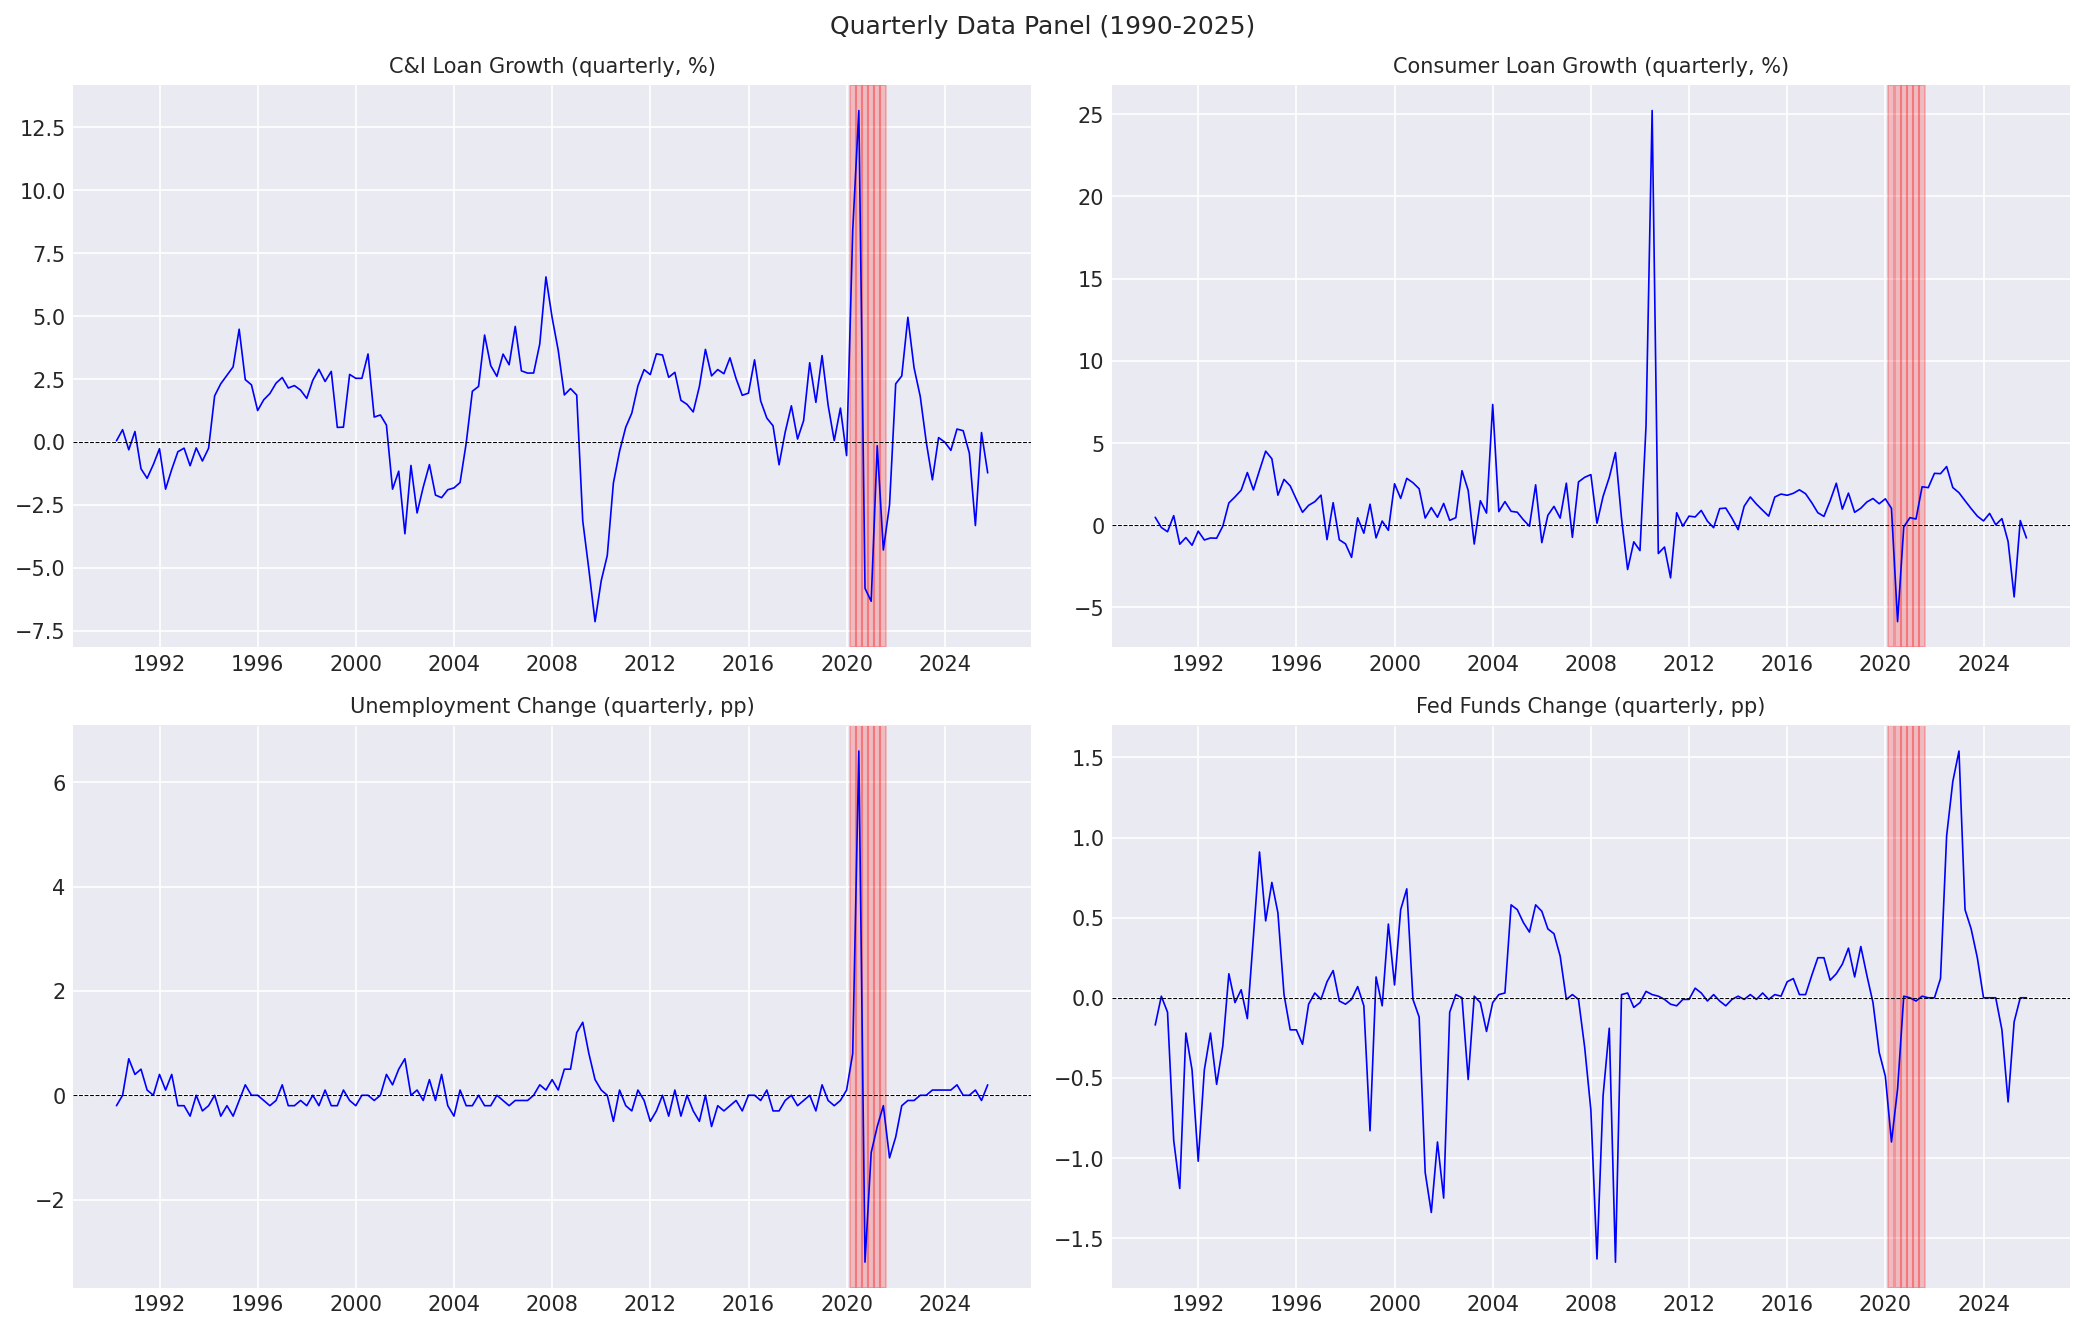

In [6]:
# Visualize quarterly data
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col, title in [
    (axes[0, 0], 'BUSLOANS_g', 'C&I Loan Growth (quarterly, %)'),
    (axes[0, 1], 'CONSUMER_g', 'Consumer Loan Growth (quarterly, %)'),
    (axes[1, 0], 'UNRATE_chg', 'Unemployment Change (quarterly, pp)'),
    (axes[1, 1], 'FEDFUNDS_chg', 'Fed Funds Change (quarterly, pp)'),
]:
    ax.plot(quarterly.index, quarterly[col], 'b-', lw=0.8)
    # Highlight COVID
    for cq in covid_quarters:
        ax.axvspan(cq - pd.Timedelta(days=45), cq + pd.Timedelta(days=45),
                   alpha=0.2, color='red')
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='black', lw=0.5, ls='--')

fig.suptitle('Quarterly Data Panel (1990-2025)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_data_panel.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 3. NGFS Scenario Paths — Interpolated to Quarterly

In [7]:
# Reconstruct NGFS level paths (same as annual notebook)
VAR_MAP = {
    'Gross Domestic Product (GDP)': {
        'diff': 'Gross Domestic Product (GDP)(combined)',
        'type': 'pct', 'label': 'GDP'},
    'Unemployment rate ; %': {
        'diff': 'Unemployment rate ; %(combined)',
        'type': 'abs', 'label': 'UNRATE'},
    'Inflation rate ; %': {
        'diff': 'Inflation rate ; %(combined)',
        'type': 'abs', 'label': 'CPI_INFLATION'},
    'Central bank Intervention rate (policy interest rate) ; %': {
        'diff': 'Central bank Intervention rate (policy interest rate) ; %(combined)',
        'type': 'abs', 'label': 'FEDFUNDS'},
    'Long term interest rate ; %': {
        'diff': 'Long term interest rate ; %(combined)',
        'type': 'abs', 'label': 'DGS10'},
}

def reconstruct_all_models(nigem_us, var_map, year_cols, models):
    all_levels = {}
    for model in models:
        model_short = model.split('[')[1].rstrip(']') if '[' in model else model
        for var_level, info in var_map.items():
            baseline = nigem_us[
                (nigem_us['Variable'] == var_level) &
                (nigem_us['Model'] == model) &
                (nigem_us['Scenario'] == 'Baseline')
            ]
            if baseline.empty:
                continue
            base_vals = baseline.iloc[0][year_cols].astype(float).values

            result = pd.DataFrame(index=[int(y) for y in year_cols])
            result.index.name = 'Year'
            result['Baseline'] = base_vals

            diffs = nigem_us[
                (nigem_us['Variable'] == info['diff']) &
                (nigem_us['Model'] == model)
            ]
            for _, row in diffs.iterrows():
                scen = row['Scenario']
                diff_vals = row[year_cols].astype(float).values
                if info['type'] == 'pct':
                    result[scen] = base_vals * (1 + diff_vals / 100)
                else:
                    result[scen] = base_vals + diff_vals

            all_levels[(model_short, info['label'])] = result

    return all_levels

ngfs_levels = reconstruct_all_models(nigem_us, VAR_MAP, year_cols, MODELS)
print(f'Reconstructed {len(ngfs_levels)} level paths')

Reconstructed 15 level paths


In [8]:
def ngfs_to_quarterly_transformations(ngfs_levels, key_scenarios):
    """Convert annual NGFS level paths to quarterly growth rates/changes.
    
    Strategy: Interpolate annual levels to quarterly using linear interpolation,
    then compute quarterly growth rates/changes from the interpolated levels.
    This assumes smooth within-year transitions — defensible for macro variables
    like GDP and unemployment that don't jump quarter-to-quarter.
    """
    scenario_paths = {}
    models_in_data = sorted(set(m for m, v in ngfs_levels.keys()))

    for model in models_in_data:
        for scenario in key_scenarios:
            # First, interpolate each variable from annual to quarterly levels
            quarterly_levels = {}
            
            for var_label in ['GDP', 'UNRATE', 'CPI_INFLATION', 'FEDFUNDS', 'DGS10']:
                key = (model, var_label)
                if key not in ngfs_levels:
                    continue
                level_df = ngfs_levels[key]
                if scenario not in level_df.columns:
                    continue
                
                annual_series = level_df[scenario]
                
                # Create quarterly date index, place annual values at Q4 (year-end)
                first_year = annual_series.index[0]
                last_year = annual_series.index[-1]
                q_index = pd.date_range(
                    start=f'{first_year}-03-31',
                    end=f'{last_year}-12-31',
                    freq='QE'
                )
                
                # Place annual values at Q4 of each year
                q_series = pd.Series(index=q_index, dtype=float)
                for year in annual_series.index:
                    q4_date = pd.Timestamp(f'{year}-12-31')
                    if q4_date in q_series.index:
                        q_series[q4_date] = annual_series[year]
                
                # Linear interpolation to fill Q1-Q3
                q_series = q_series.interpolate(method='linear')
                quarterly_levels[var_label] = q_series
            
            # Now compute quarterly transformations from interpolated levels
            path = pd.DataFrame(index=quarterly_levels['GDP'].index)
            
            # GDP: quarterly log growth rate (x100)
            gdp_q = quarterly_levels['GDP']
            path['GDPC1_g'] = 100 * np.log(gdp_q / gdp_q.shift(1))
            
            # CPI inflation: NiGEM gives annual rate, convert to quarterly
            # Annual inflation rate -> quarterly by dividing by 4
            cpi_q = quarterly_levels['CPI_INFLATION']
            path['CPIAUCSL_g'] = cpi_q / 4  # approximate quarterly CPI growth
            
            # Unemployment: quarterly change
            ur_q = quarterly_levels['UNRATE']
            path['UNRATE_chg'] = ur_q.diff()
            
            # Fed Funds: quarterly change
            ff_q = quarterly_levels['FEDFUNDS']
            path['FEDFUNDS_chg'] = ff_q.diff()
            
            # DGS10: quarterly change
            dgs_q = quarterly_levels['DGS10']
            path['DGS10_chg'] = dgs_q.diff()
            
            path = path.dropna()
            # Use quarterly period index for clarity
            scenario_paths[(model, scenario)] = path
    
    return scenario_paths

ngfs_q_paths = ngfs_to_quarterly_transformations(ngfs_levels, KEY_SCENARIOS)

print(f'Generated {len(ngfs_q_paths)} quarterly scenario paths')
for (model, scen), df in sorted(ngfs_q_paths.items()):
    label = f'{model[:25]} / {KEY_SCENARIO_SHORT.get(scen, scen)}'
    print(f'  {label:45s} | quarters: {len(df)} | {df.index[0].date()} to {df.index[-1].date()}')
    print(f'    GDP_g: {df["GDPC1_g"].mean():.3f}%/q  UNRATE_chg: {df["UNRATE_chg"].mean():.4f}pp/q')

Generated 9 quarterly scenario paths
  GCAM 6.0 NGFS / Delayed Trans.                | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.301%/q  UNRATE_chg: 0.0081pp/q
  GCAM 6.0 NGFS / NDCs                          | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.295%/q  UNRATE_chg: 0.0075pp/q
  GCAM 6.0 NGFS / Net Zero                      | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.327%/q  UNRATE_chg: 0.0068pp/q
  MESSAGEix-GLOBIOM 2.0-M-R / Delayed Trans.    | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.335%/q  UNRATE_chg: 0.0078pp/q
  MESSAGEix-GLOBIOM 2.0-M-R / NDCs              | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.338%/q  UNRATE_chg: 0.0074pp/q
  MESSAGEix-GLOBIOM 2.0-M-R / Net Zero          | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.356%/q  UNRATE_chg: 0.0070pp/q
  REMIND-MAgPIE 3.3-4.8 / Delayed Trans.        | quarters: 112 | 2023-03-31 to 2050-12-31
    GDP_g: 0.299%/q  UNRATE_chg: 0.0072pp/q
  REMIND-MAgPIE 3.

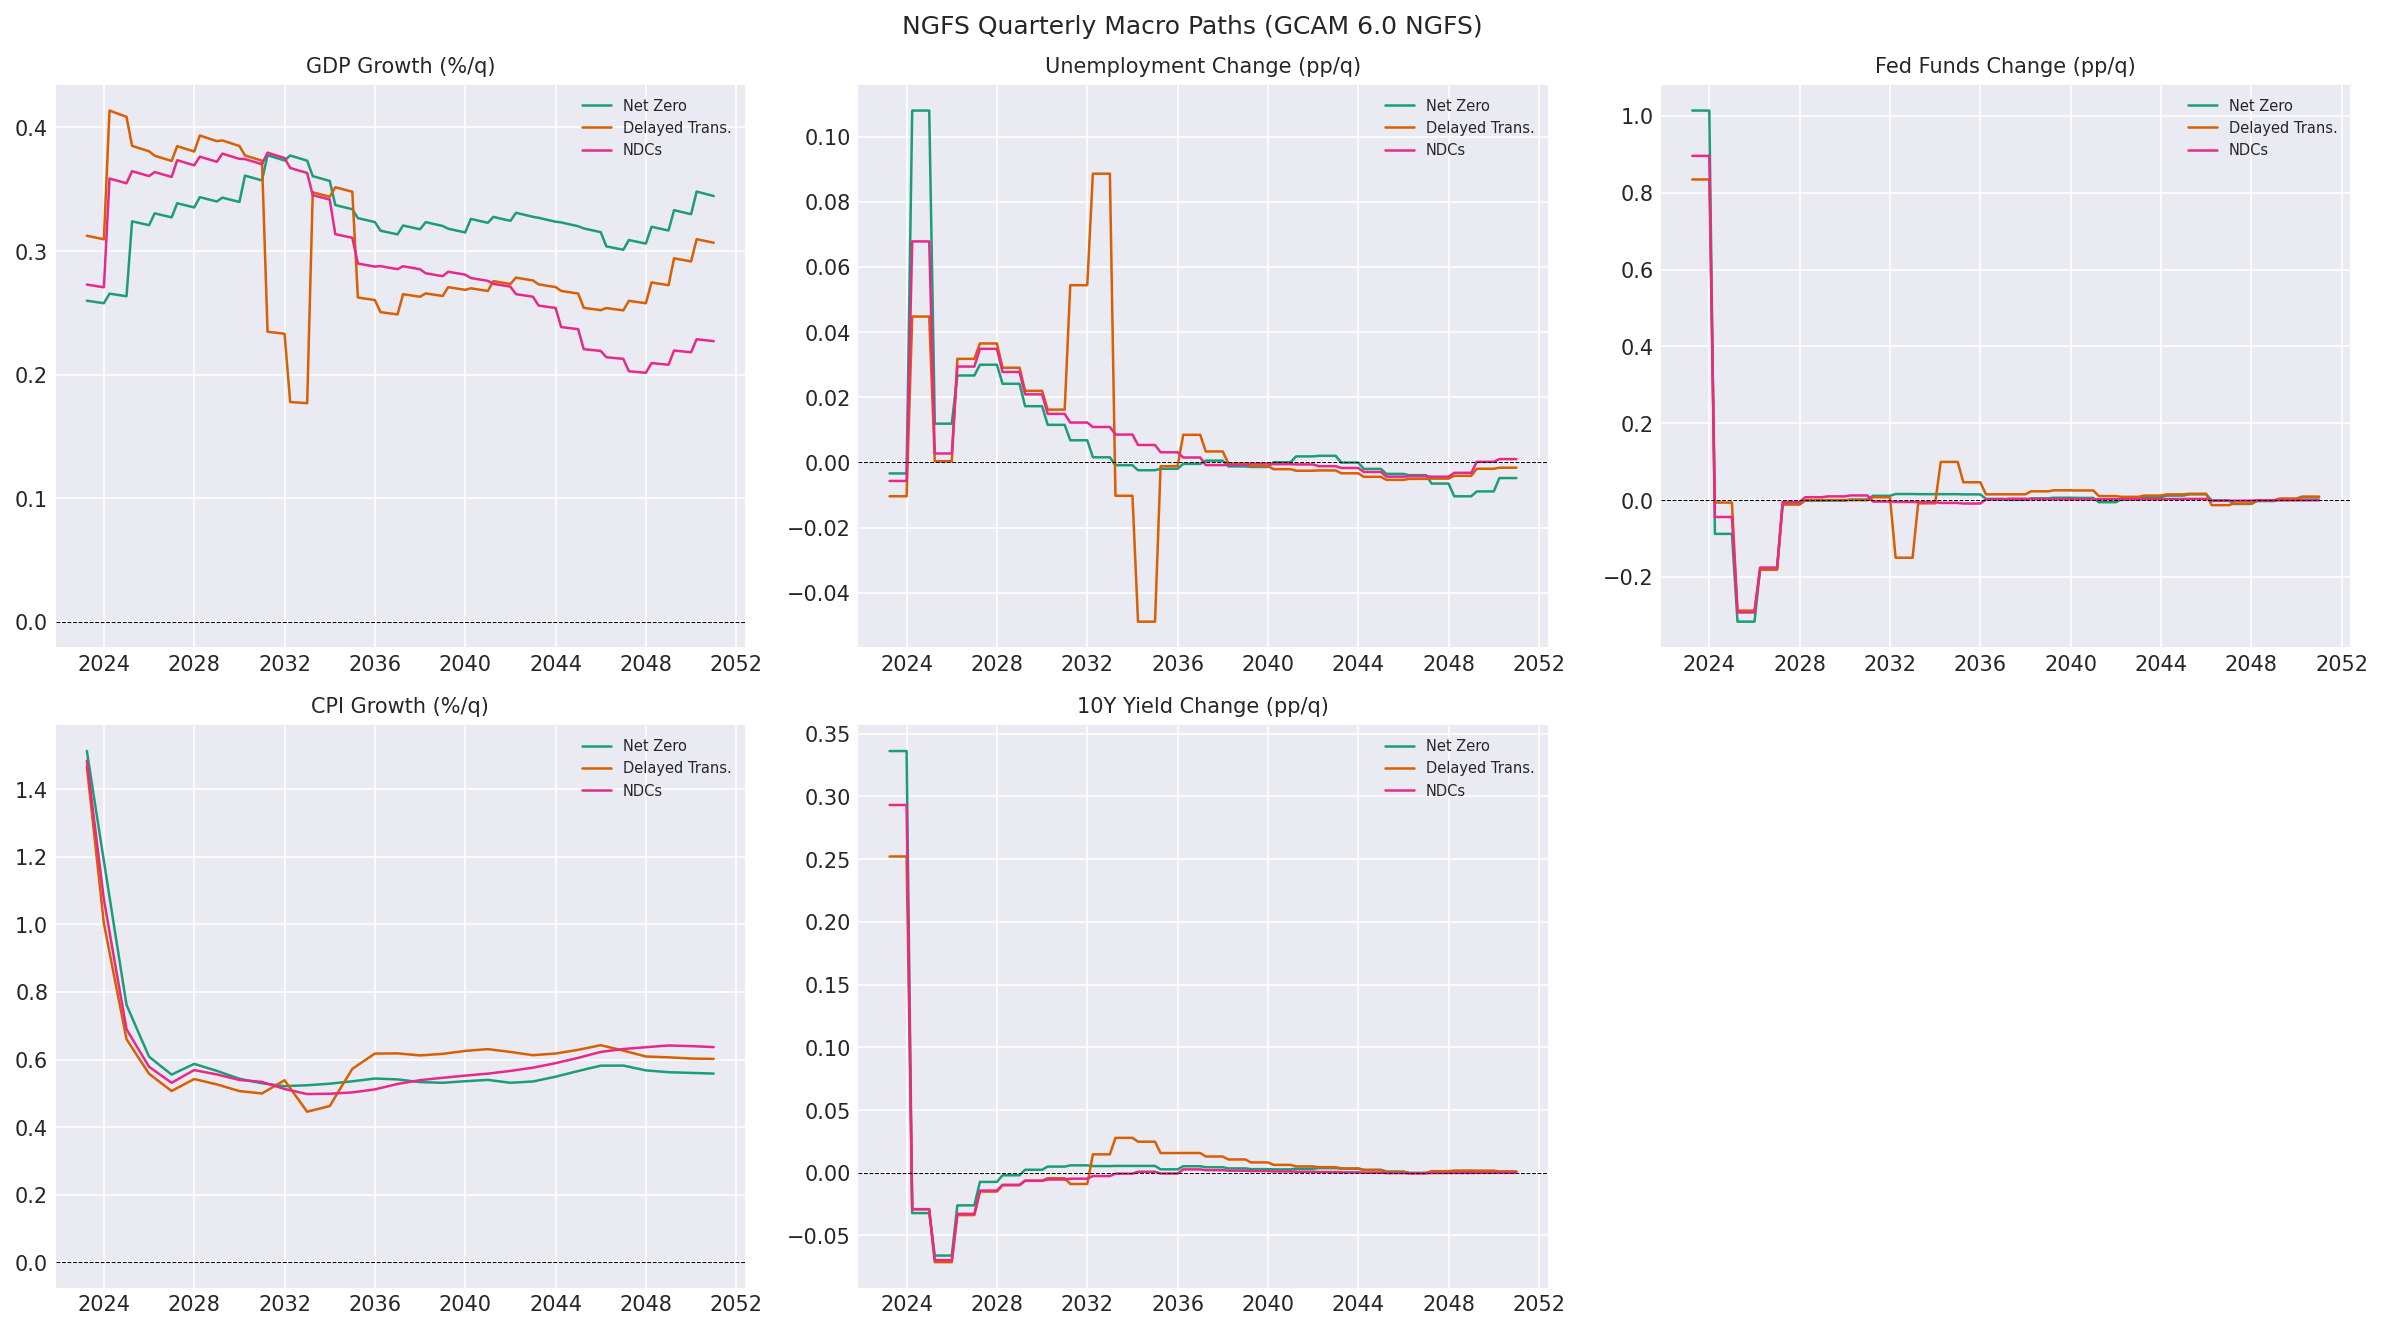

In [9]:
# Visualize NGFS quarterly paths for GCAM
gcam = [m for m in MODEL_SHORT.values() if 'GCAM' in m][0]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_vars = [
    ('GDPC1_g', 'GDP Growth (%/q)'),
    ('UNRATE_chg', 'Unemployment Change (pp/q)'),
    ('FEDFUNDS_chg', 'Fed Funds Change (pp/q)'),
    ('CPIAUCSL_g', 'CPI Growth (%/q)'),
    ('DGS10_chg', '10Y Yield Change (pp/q)'),
]

for idx, (var, title) in enumerate(plot_vars):
    ax = axes.flat[idx]
    for scen in KEY_SCENARIOS:
        key = (gcam, scen)
        if key in ngfs_q_paths and var in ngfs_q_paths[key].columns:
            path = ngfs_q_paths[key]
            ax.plot(path.index, path[var],
                    color=SCENARIO_COLORS.get(scen, 'gray'),
                    label=KEY_SCENARIO_SHORT.get(scen, scen), lw=1.2)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)  # hide extra subplot
fig.suptitle(f'NGFS Quarterly Macro Paths ({gcam})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_ngfs_paths.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 4. AR Baselines (Quarterly)

In [10]:
def fit_ar_baseline(series, max_p=8, name=''):
    s = series.dropna()
    results = []
    for p in range(1, max_p + 1):
        try:
            m = AutoReg(s, lags=p, old_names=False).fit()
            results.append({'p': p, 'AIC': m.aic, 'BIC': m.bic,
                           'RMSE': np.sqrt(np.mean(m.resid**2))})
        except Exception:
            continue
    res_df = pd.DataFrame(results)
    best_bic = res_df.loc[res_df['BIC'].idxmin()]
    p_star = int(best_bic['p'])

    model = AutoReg(s, lags=p_star, old_names=False).fit()
    lb = acorr_ljungbox(model.resid, lags=[4, 8], return_df=True)

    print(f'\n{name}: BIC selects AR({p_star})')
    print(f'  In-sample RMSE: {np.sqrt(np.mean(model.resid**2)):.3f}')
    print(f'  BIC: {model.bic:.1f}')
    print(f'  Ljung-Box p-values: lag4={lb["lb_pvalue"].iloc[0]:.3f}, lag8={lb["lb_pvalue"].iloc[1]:.3f}')
    return model, p_star, res_df

# Ex-COVID quarterly data
quarterly_excovid = quarterly[quarterly['COVID'] == 0]
print(f'Ex-COVID quarterly sample: n={len(quarterly_excovid)}')

ar_busloans_q, ar_bus_p_q, _ = fit_ar_baseline(
    quarterly_excovid['BUSLOANS_g'], max_p=8,
    name='C&I Loan Growth (quarterly, ex-COVID)')

ar_consumer_q, ar_con_p_q, _ = fit_ar_baseline(
    quarterly_excovid['CONSUMER_g'], max_p=8,
    name='Consumer Loan Growth (quarterly, ex-COVID)')

Ex-COVID quarterly sample: n=137

C&I Loan Growth (quarterly, ex-COVID): BIC selects AR(4)
  In-sample RMSE: 1.313
  BIC: 479.2
  Ljung-Box p-values: lag4=0.970, lag8=0.991

Consumer Loan Growth (quarterly, ex-COVID): BIC selects AR(3)
  In-sample RMSE: 2.569
  BIC: 657.6
  Ljung-Box p-values: lag4=1.000, lag8=1.000


## 5. Quarterly VAR — C&I Loans

In [11]:
# Prepare C&I VAR data (quarterly)
ci_vars_q = ['BUSLOANS_g', 'UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']
ci_data_q = quarterly[ci_vars_q].copy()
ci_exog_q = quarterly[['COVID']].copy()

mask = ci_data_q.notna().all(axis=1)
ci_data_q = ci_data_q[mask]
ci_exog_q = ci_exog_q.loc[ci_data_q.index]

print(f'C&I Quarterly VAR data: n={len(ci_data_q)} quarters')
print(f'  vs Annual: n=36')
print(f'\nCorrelation matrix:')
print(ci_data_q.corr().round(3))

C&I Quarterly VAR data: n=143 quarters
  vs Annual: n=36

Correlation matrix:
              BUSLOANS_g  UNRATE_chg  FEDFUNDS_chg  CPIAUCSL_g
BUSLOANS_g         1.000       0.349         0.135      -0.098
UNRATE_chg         0.349       1.000        -0.272      -0.238
FEDFUNDS_chg       0.135      -0.272         1.000       0.228
CPIAUCSL_g        -0.098      -0.238         0.228       1.000


In [12]:
# Lag order selection — can try more lags now
ci_model_q = VAR(ci_data_q, exog=ci_exog_q)
ci_lag_q = ci_model_q.select_order(maxlags=8)
print('Lag Order Selection (Quarterly C&I VAR):')
print(ci_lag_q.summary())

ci_p_q = ci_lag_q.bic
if ci_p_q == 0:
    ci_p_q = 1
print(f'\nBIC selects: VAR({ci_p_q})')
print(f'  (Annual model used VAR(1) — more lags are now feasible with {len(ci_data_q)} obs)')

ci_var_q = ci_model_q.fit(maxlags=ci_p_q)
print(f'\nVAR({ci_p_q}) estimated on {ci_var_q.nobs} observations')
print(f'Parameters per equation: {ci_var_q.k_ar * len(ci_vars_q) + 1 + 1}')
print(f'Observations per parameter: {ci_var_q.nobs / (ci_var_q.k_ar * len(ci_vars_q) + 2):.1f}')

Lag Order Selection (Quarterly C&I VAR):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -1.522      -1.350      0.2183      -1.452
1      -2.847     -2.330*     0.05803      -2.637
2      -3.037      -2.176     0.04803     -2.687*
3      -2.990      -1.785     0.05042      -2.501
4      -3.056      -1.507     0.04737      -2.426
5     -3.198*      -1.305    0.04131*      -2.429
6      -3.105     -0.8666     0.04572      -2.195
7      -3.034     -0.4520     0.04958      -1.985
8      -3.074     -0.1470     0.04834      -1.884
-------------------------------------------------

BIC selects: VAR(1)
  (Annual model used VAR(1) — more lags are now feasible with 143 obs)

VAR(1) estimated on 142 observations
Parameters per equation: 6
Observations per parameter: 23.7


In [13]:
# C&I loan equation coefficients
print('=' * 70)
print(f'BUSLOANS_g equation from quarterly VAR({ci_p_q}):')
print('=' * 70)

params = ci_var_q.params['BUSLOANS_g']
pvals = ci_var_q.pvalues['BUSLOANS_g']
stderr = ci_var_q.stderr['BUSLOANS_g']

print(f'{"Variable":30s} {"Coef":>10s} {"Std Err":>12s} {"t-stat":>10s} {"p-value":>10s}')
print('-' * 72)
for var in params.index:
    sig = '***' if pvals[var] < 0.01 else '**' if pvals[var] < 0.05 else '*' if pvals[var] < 0.1 else ''
    print(f'{var:30s} {params[var]:10.4f} {stderr[var]:12.4f} {params[var]/stderr[var]:10.3f} {pvals[var]:10.3f} {sig}')

print(f'\nResidual correlation matrix:')
print(ci_var_q.resid_corr.round(3))

BUSLOANS_g equation from quarterly VAR(1):
Variable                             Coef      Std Err     t-stat    p-value
------------------------------------------------------------------------
const                              0.0459       0.2383      0.192      0.847 
COVID                              0.2705       0.7606      0.356      0.722 
L1.BUSLOANS_g                      0.7834       0.0625     12.525      0.000 ***
L1.UNRATE_chg                     -1.7702       0.2486     -7.121      0.000 ***
L1.FEDFUNDS_chg                   -0.0898       0.3587     -0.250      0.802 
L1.CPIAUCSL_g                      0.2039       0.2490      0.819      0.413 

Residual correlation matrix:
[[ 1.     0.448 -0.043 -0.161]
 [ 0.448  1.    -0.161 -0.237]
 [-0.043 -0.161  1.     0.299]
 [-0.161 -0.237  0.299  1.   ]]


In [14]:
# Granger causality (quarterly) — KEY COMPARISON with annual
print('Granger Causality Tests (Quarterly): X -> BUSLOANS_g')
print('H0: X does NOT Granger-cause BUSLOANS_g')
print('=' * 60)

for var in ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']:
    try:
        test_data = ci_data_q[['BUSLOANS_g', var]].dropna()
        gc = grangercausalitytests(test_data, maxlag=min(ci_p_q + 1, 4), verbose=False)
        best_p = min(gc[lag][0]['ssr_ftest'][1] for lag in gc)
        sig = '***' if best_p < 0.01 else '**' if best_p < 0.05 else '*' if best_p < 0.1 else ''
        print(f'  {var:20s} -> BUSLOANS_g: best F p-val = {best_p:.4f} {sig}')
    except Exception as e:
        print(f'  {var:20s} -> BUSLOANS_g: Error - {e}')

print(f'\nCompare with ANNUAL results:')
print(f'  UNRATE_chg:   annual p=0.0004 vs quarterly above')
print(f'  FEDFUNDS_chg: annual p=0.0193 vs quarterly above')
print(f'  CPIAUCSL_g:   annual p=0.3900 vs quarterly above')

Granger Causality Tests (Quarterly): X -> BUSLOANS_g
H0: X does NOT Granger-cause BUSLOANS_g
  UNRATE_chg           -> BUSLOANS_g: best F p-val = 0.0000 ***
  FEDFUNDS_chg         -> BUSLOANS_g: best F p-val = 0.0316 **
  CPIAUCSL_g           -> BUSLOANS_g: best F p-val = 0.0227 **

Compare with ANNUAL results:
  UNRATE_chg:   annual p=0.0004 vs quarterly above
  FEDFUNDS_chg: annual p=0.0193 vs quarterly above
  CPIAUCSL_g:   annual p=0.3900 vs quarterly above


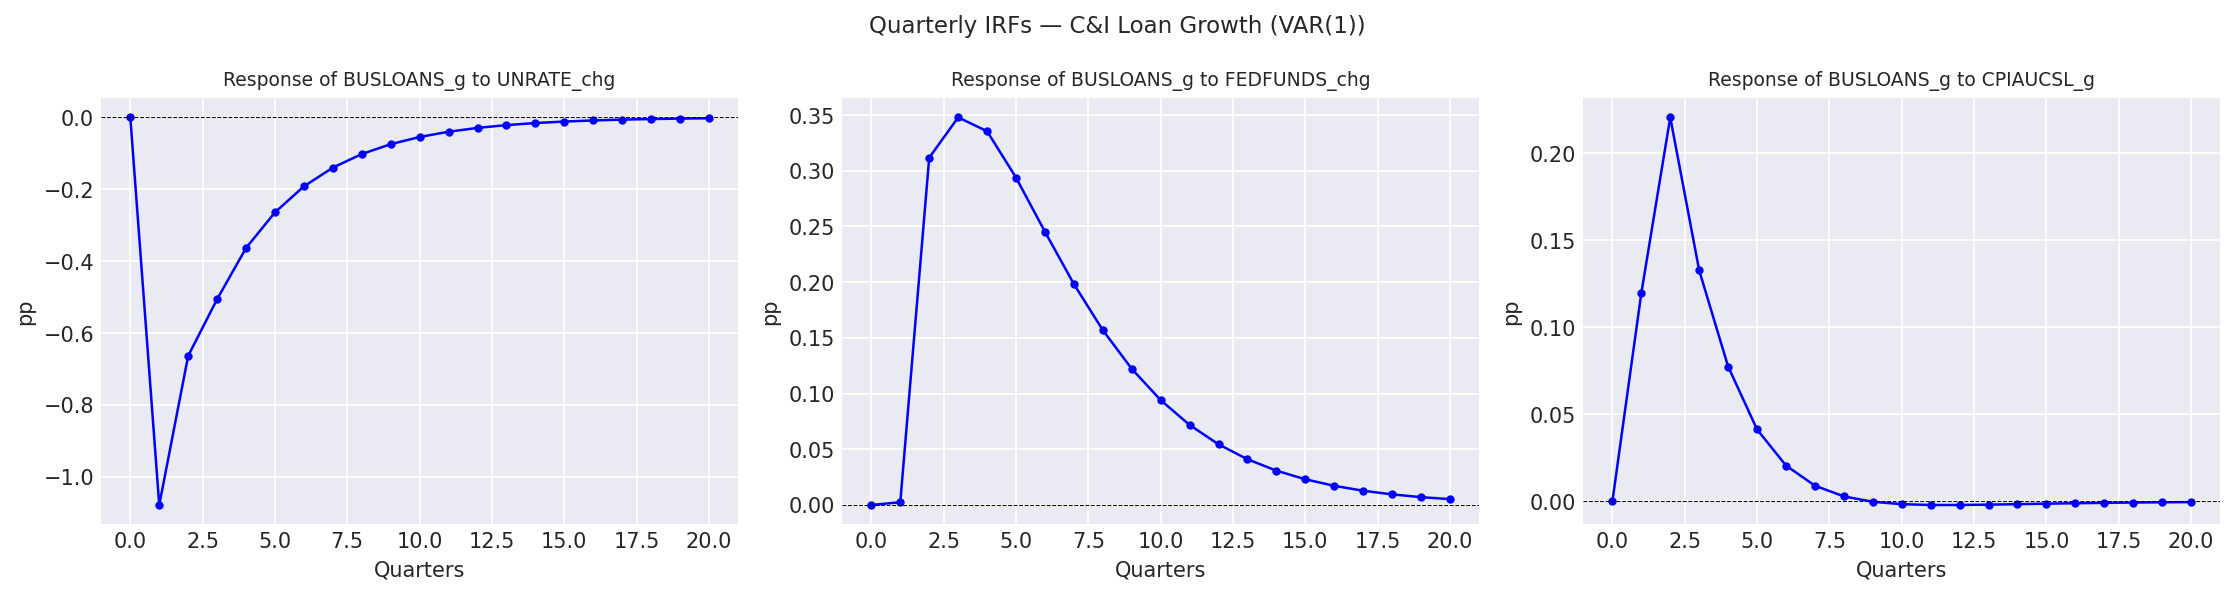

In [15]:
# IRFs (quarterly)
irf_ci_q = ci_var_q.irf(periods=20)  # 20 quarters = 5 years
irf_data_q = irf_ci_q.orth_irfs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
impulse_vars = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']
target_idx = ci_vars_q.index('BUSLOANS_g')

for ax, imp_var in zip(axes, impulse_vars):
    imp_idx = ci_vars_q.index(imp_var)
    response = irf_data_q[:, target_idx, imp_idx]
    ax.plot(range(len(response)), response, 'b-o', ms=3, lw=1.2)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'Response of BUSLOANS_g to {imp_var}', fontsize=9)
    ax.set_xlabel('Quarters')
    ax.set_ylabel('pp')

fig.suptitle(f'Quarterly IRFs — C&I Loan Growth (VAR({ci_p_q}))', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_irf_ci.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [16]:
# C&I residual diagnostics
resid_ci_q = ci_var_q.resid['BUSLOANS_g']
lb_ci_q = acorr_ljungbox(resid_ci_q, lags=[4, 8, 12], return_df=True)
print('C&I VAR Residual Diagnostics (Quarterly):')
print(f'  Ljung-Box p-values: lag4={lb_ci_q["lb_pvalue"].iloc[0]:.3f}, '
      f'lag8={lb_ci_q["lb_pvalue"].iloc[1]:.3f}, lag12={lb_ci_q["lb_pvalue"].iloc[2]:.3f}')
print(f'  Residual std: {resid_ci_q.std():.3f}')
adf_resid = adfuller(resid_ci_q)
print(f'  ADF on residuals: stat={adf_resid[0]:.3f}, p={adf_resid[1]:.4f}')

C&I VAR Residual Diagnostics (Quarterly):
  Ljung-Box p-values: lag4=0.047, lag8=0.166, lag12=0.300
  Residual std: 1.765
  ADF on residuals: stat=-8.117, p=0.0000


## 6. Quarterly VAR — Consumer Loans

In [17]:
# Prepare Consumer VAR data (quarterly)
con_vars_q = ['CONSUMER_g', 'UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']
con_data_q = quarterly[con_vars_q].copy()
con_exog_q = quarterly[['COVID']].copy()

mask = con_data_q.notna().all(axis=1)
con_data_q = con_data_q[mask]
con_exog_q = con_exog_q.loc[con_data_q.index]

print(f'Consumer Quarterly VAR data: n={len(con_data_q)} quarters')
print(f'\nCorrelation matrix:')
print(con_data_q.corr().round(3))

Consumer Quarterly VAR data: n=143 quarters

Correlation matrix:
              CONSUMER_g  UNRATE_chg  FEDFUNDS_chg  CPIAUCSL_g  DGS10_chg
CONSUMER_g         1.000      -0.236         0.119      -0.068     -0.121
UNRATE_chg        -0.236       1.000        -0.272      -0.238     -0.086
FEDFUNDS_chg       0.119      -0.272         1.000       0.228      0.248
CPIAUCSL_g        -0.068      -0.238         0.228       1.000      0.352
DGS10_chg         -0.121      -0.086         0.248       0.352      1.000


In [18]:
# Lag order selection
con_model_q = VAR(con_data_q, exog=con_exog_q)
con_lag_q = con_model_q.select_order(maxlags=8)
print('Lag Order Selection (Quarterly Consumer VAR):')
print(con_lag_q.summary())

con_p_q = con_lag_q.bic
if con_p_q == 0:
    con_p_q = 1
print(f'\nBIC selects: VAR({con_p_q})')
print(f'  (Annual model used VAR(1))')

con_var_q = con_model_q.fit(maxlags=con_p_q)
print(f'\nVAR({con_p_q}) estimated on {con_var_q.nobs} observations')
print(f'Parameters per equation: {con_var_q.k_ar * len(con_vars_q) + 1 + 1}')
print(f'Observations per parameter: {con_var_q.nobs / (con_var_q.k_ar * len(con_vars_q) + 2):.1f}')

Lag Order Selection (Quarterly Consumer VAR):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.963      -2.748     0.05167      -2.875
1      -3.601     -2.847*     0.02732     -3.295*
2      -3.446      -2.154     0.03196      -2.921
3      -3.316      -1.486     0.03655      -2.572
4      -3.299     -0.9317     0.03747      -2.337
5      -3.290     -0.3851     0.03827      -2.110
6     -3.660*     -0.2172    0.02693*      -2.261
7      -3.519      0.4623     0.03184      -1.901
8      -3.651      0.8682     0.02889      -1.815
-------------------------------------------------

BIC selects: VAR(1)
  (Annual model used VAR(1))

VAR(1) estimated on 142 observations
Parameters per equation: 7
Observations per parameter: 20.3


In [19]:
# Consumer loan equation coefficients
print('=' * 70)
print(f'CONSUMER_g equation from quarterly VAR({con_p_q}):')
print('=' * 70)

params = con_var_q.params['CONSUMER_g']
pvals = con_var_q.pvalues['CONSUMER_g']
stderr = con_var_q.stderr['CONSUMER_g']

print(f'{"Variable":30s} {"Coef":>10s} {"Std Err":>12s} {"t-stat":>10s} {"p-value":>10s}')
print('-' * 72)
for var in params.index:
    sig = '***' if pvals[var] < 0.01 else '**' if pvals[var] < 0.05 else '*' if pvals[var] < 0.1 else ''
    print(f'{var:30s} {params[var]:10.4f} {stderr[var]:12.4f} {params[var]/stderr[var]:10.3f} {pvals[var]:10.3f} {sig}')

CONSUMER_g equation from quarterly VAR(1):
Variable                             Coef      Std Err     t-stat    p-value
------------------------------------------------------------------------
const                              0.9939       0.3623      2.743      0.006 ***
COVID                             -0.9136       1.1099     -0.823      0.410 
L1.CONSUMER_g                      0.1780       0.0873      2.038      0.042 **
L1.UNRATE_chg                     -0.0315       0.3414     -0.092      0.926 
L1.FEDFUNDS_chg                    0.8433       0.5146      1.639      0.101 
L1.CPIAUCSL_g                     -0.0213       0.3821     -0.056      0.955 
L1.DGS10_chg                       0.2761       0.4765      0.579      0.562 


In [20]:
# Granger causality (quarterly) — CRITICAL: does unemployment now matter for consumer loans?
print('Granger Causality Tests (Quarterly): X -> CONSUMER_g')
print('H0: X does NOT Granger-cause CONSUMER_g')
print('=' * 60)

for var in ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']:
    try:
        test_data = con_data_q[['CONSUMER_g', var]].dropna()
        gc = grangercausalitytests(test_data, maxlag=min(con_p_q + 1, 4), verbose=False)
        best_p = min(gc[lag][0]['ssr_ftest'][1] for lag in gc)
        sig = '***' if best_p < 0.01 else '**' if best_p < 0.05 else '*' if best_p < 0.1 else ''
        print(f'  {var:20s} -> CONSUMER_g: best F p-val = {best_p:.4f} {sig}')
    except Exception as e:
        print(f'  {var:20s} -> CONSUMER_g: Error - {e}')

print(f'\nCompare with ANNUAL results:')
print(f'  UNRATE_chg:   annual p=0.8100 (NOT significant) vs quarterly above')
print(f'  FEDFUNDS_chg: annual p=0.1594 vs quarterly above')
print(f'  DGS10_chg:    annual p=0.0232 vs quarterly above')
print(f'\n--> Does unemployment now Granger-cause consumer loans at quarterly frequency?')

Granger Causality Tests (Quarterly): X -> CONSUMER_g
H0: X does NOT Granger-cause CONSUMER_g
  UNRATE_chg           -> CONSUMER_g: best F p-val = 0.4899 
  FEDFUNDS_chg         -> CONSUMER_g: best F p-val = 0.0402 **
  CPIAUCSL_g           -> CONSUMER_g: best F p-val = 0.4067 
  DGS10_chg            -> CONSUMER_g: best F p-val = 0.0480 **

Compare with ANNUAL results:
  UNRATE_chg:   annual p=0.8100 (NOT significant) vs quarterly above
  FEDFUNDS_chg: annual p=0.1594 vs quarterly above
  DGS10_chg:    annual p=0.0232 vs quarterly above

--> Does unemployment now Granger-cause consumer loans at quarterly frequency?


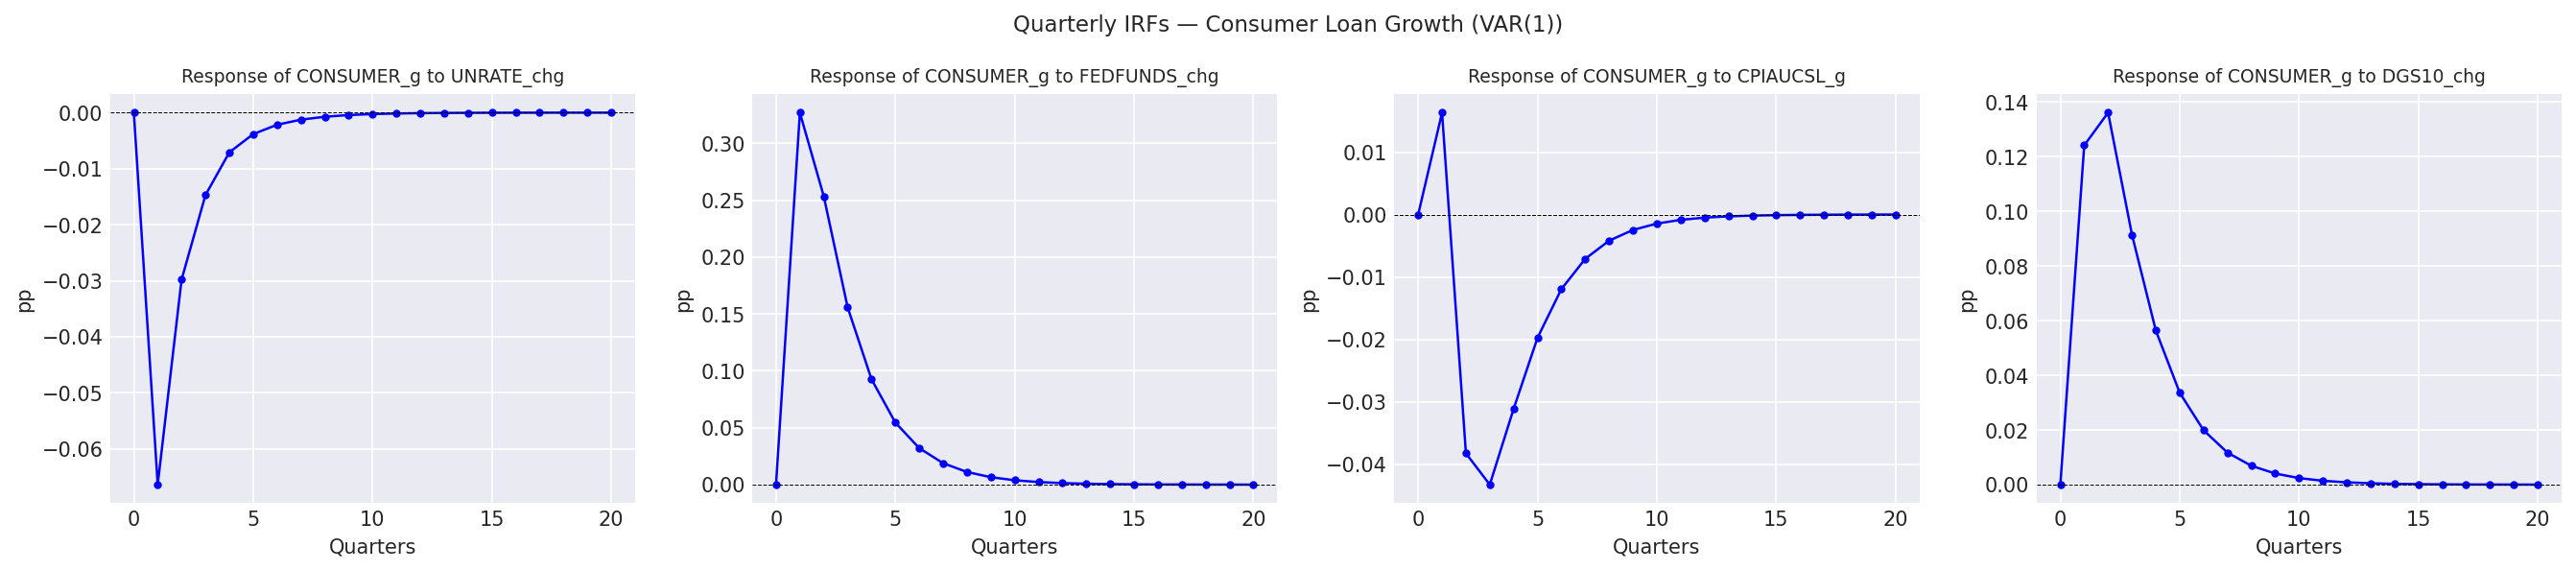

In [21]:
# Consumer IRFs (quarterly)
irf_con_q = con_var_q.irf(periods=20)
irf_con_data_q = irf_con_q.orth_irfs

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
con_impulse_vars = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']
target_idx = con_vars_q.index('CONSUMER_g')

for ax, imp_var in zip(axes, con_impulse_vars):
    imp_idx = con_vars_q.index(imp_var)
    response = irf_con_data_q[:, target_idx, imp_idx]
    ax.plot(range(len(response)), response, 'b-o', ms=3, lw=1.2)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'Response of CONSUMER_g to {imp_var}', fontsize=9)
    ax.set_xlabel('Quarters')
    ax.set_ylabel('pp')

fig.suptitle(f'Quarterly IRFs — Consumer Loan Growth (VAR({con_p_q}))', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_irf_consumer.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [22]:
# Consumer residual diagnostics
resid_con_q = con_var_q.resid['CONSUMER_g']
lb_con_q = acorr_ljungbox(resid_con_q, lags=[4, 8, 12], return_df=True)
print('Consumer VAR Residual Diagnostics (Quarterly):')
print(f'  Ljung-Box p-values: lag4={lb_con_q["lb_pvalue"].iloc[0]:.3f}, '
      f'lag8={lb_con_q["lb_pvalue"].iloc[1]:.3f}, lag12={lb_con_q["lb_pvalue"].iloc[2]:.3f}')
print(f'  Residual std: {resid_con_q.std():.3f}')
adf_resid = adfuller(resid_con_q)
print(f'  ADF on residuals: stat={adf_resid[0]:.3f}, p={adf_resid[1]:.4f}')

Consumer VAR Residual Diagnostics (Quarterly):
  Ljung-Box p-values: lag4=0.457, lag8=0.660, lag12=0.854
  Residual std: 2.554
  ADF on residuals: stat=-11.718, p=0.0000


## 7. Pseudo Out-of-Sample Evaluation (Quarterly)

In [23]:
def pseudo_oos_ar_q(series, start_date, p, covid_index):
    """Expanding-window 1-step-ahead AR forecasts on quarterly data."""
    series_clean = series.dropna()  # Drop NaN before OOS
    forecasts, actuals, eval_dates = [], [], []
    all_dates = series_clean.index.tolist()
    start_idx = next(i for i, d in enumerate(all_dates) if d >= start_date)

    for t_idx in range(start_idx, len(all_dates)):
        t = all_dates[t_idx]
        if t in covid_index:
            continue
        train = series_clean.loc[:all_dates[t_idx - 1]]
        if len(train) < p + 10:
            continue
        try:
            model = AutoReg(train, lags=p, old_names=False).fit()
            fc = model.forecast(steps=1).iloc[0]
            forecasts.append(fc)
            actuals.append(series_clean.loc[t])
            eval_dates.append(t)
        except Exception as e:
            continue

    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2)) if len(forecasts) > 0 else np.nan
    return rmse, forecasts, actuals, eval_dates


def pseudo_oos_var_q(endog, exog_full, start_date, p, target_col, covid_index):
    """Expanding-window 1-step-ahead VAR forecasts on quarterly data."""
    forecasts, actuals, eval_dates = [], [], []
    all_dates = endog.index.tolist()
    start_idx = next(i for i, d in enumerate(all_dates) if d >= start_date)

    for t_idx in range(start_idx, len(all_dates)):
        t = all_dates[t_idx]
        if t in covid_index:
            continue
        train_endog = endog.loc[:all_dates[t_idx - 1]]
        train_exog = exog_full.loc[:all_dates[t_idx - 1]]
        if len(train_endog) < p + 10:
            continue
        try:
            model = VAR(train_endog, exog=train_exog).fit(maxlags=p)
            last_obs = train_endog.values[-p:]
            fc_exog = exog_full.loc[[t]].values
            fc = model.forecast(y=last_obs, steps=1, exog_future=fc_exog)
            target_idx = list(endog.columns).index(target_col)
            forecasts.append(fc[0, target_idx])
            actuals.append(endog.loc[t, target_col])
            eval_dates.append(t)
        except Exception:
            continue

    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2)) if len(forecasts) > 0 else np.nan
    return rmse, forecasts, actuals, eval_dates


# Start OOS eval from 2005 Q1
start_eval_q = pd.Timestamp('2005-03-31')

print('Pseudo Out-of-Sample Evaluation (Quarterly, 1-step ahead, excl. COVID)')
print('=' * 70)

# C&I
rmse_ar_ci_q, fc_ar_ci_q, act_ci_q, dates_ci_q = pseudo_oos_ar_q(
    quarterly['BUSLOANS_g'], start_eval_q, ar_bus_p_q, set(covid_quarters))
rmse_var_ci_q, fc_var_ci_q, act_ci_var_q, dates_ci_var_q = pseudo_oos_var_q(
    ci_data_q, ci_exog_q, start_eval_q, ci_p_q, 'BUSLOANS_g', set(covid_quarters))

print(f'\nC&I Loan Growth (quarterly):')
print(f'  AR({ar_bus_p_q})  RMSE = {rmse_ar_ci_q:.3f}  (eval quarters: {len(dates_ci_q)})')
print(f'  VAR({ci_p_q})  RMSE = {rmse_var_ci_q:.3f}  (eval quarters: {len(dates_ci_var_q)})')
if rmse_ar_ci_q > 0 and not np.isnan(rmse_ar_ci_q):
    print(f'  Improvement: {(1 - rmse_var_ci_q/rmse_ar_ci_q)*100:.1f}%')

# Consumer
rmse_ar_con_q, fc_ar_con_q, act_con_q, dates_con_q = pseudo_oos_ar_q(
    quarterly['CONSUMER_g'], start_eval_q, ar_con_p_q, set(covid_quarters))
rmse_var_con_q, fc_var_con_q, act_con_var_q, dates_con_var_q = pseudo_oos_var_q(
    con_data_q, con_exog_q, start_eval_q, con_p_q, 'CONSUMER_g', set(covid_quarters))

print(f'\nConsumer Loan Growth (quarterly):')
print(f'  AR({ar_con_p_q})  RMSE = {rmse_ar_con_q:.3f}  (eval quarters: {len(dates_con_q)})')
print(f'  VAR({con_p_q})  RMSE = {rmse_var_con_q:.3f}  (eval quarters: {len(dates_con_var_q)})')
if rmse_ar_con_q > 0 and not np.isnan(rmse_ar_con_q):
    print(f'  Improvement: {(1 - rmse_var_con_q/rmse_ar_con_q)*100:.1f}%')

# Summary comparison
print(f'\n{"=" * 70}')
print('FREQUENCY COMPARISON: Annual vs Quarterly OOS Performance')
print(f'{"=" * 70}')
print(f'{"":20s} {"Annual AR":>12s} {"Annual VAR":>12s} {"Qrtly AR":>12s} {"Qrtly VAR":>12s}')
print(f'{"C&I RMSE":20s} {10.09:12.2f} {9.05:12.2f} {rmse_ar_ci_q:12.2f} {rmse_var_ci_q:12.2f}')
print(f'{"Consumer RMSE":20s} {16.85:12.2f} {14.03:12.2f} {rmse_ar_con_q:12.2f} {rmse_var_con_q:12.2f}')


Pseudo Out-of-Sample Evaluation (Quarterly, 1-step ahead, excl. COVID)



C&I Loan Growth (quarterly):
  AR(4)  RMSE = 1.491  (eval quarters: 77)
  VAR(1)  RMSE = 1.317  (eval quarters: 77)
  Improvement: 11.7%



Consumer Loan Growth (quarterly):
  AR(3)  RMSE = 4.202  (eval quarters: 77)
  VAR(1)  RMSE = 3.889  (eval quarters: 77)
  Improvement: 7.5%

FREQUENCY COMPARISON: Annual vs Quarterly OOS Performance
                        Annual AR   Annual VAR     Qrtly AR    Qrtly VAR
C&I RMSE                    10.09         9.05         1.49         1.32
Consumer RMSE               16.85        14.03         4.20         3.89


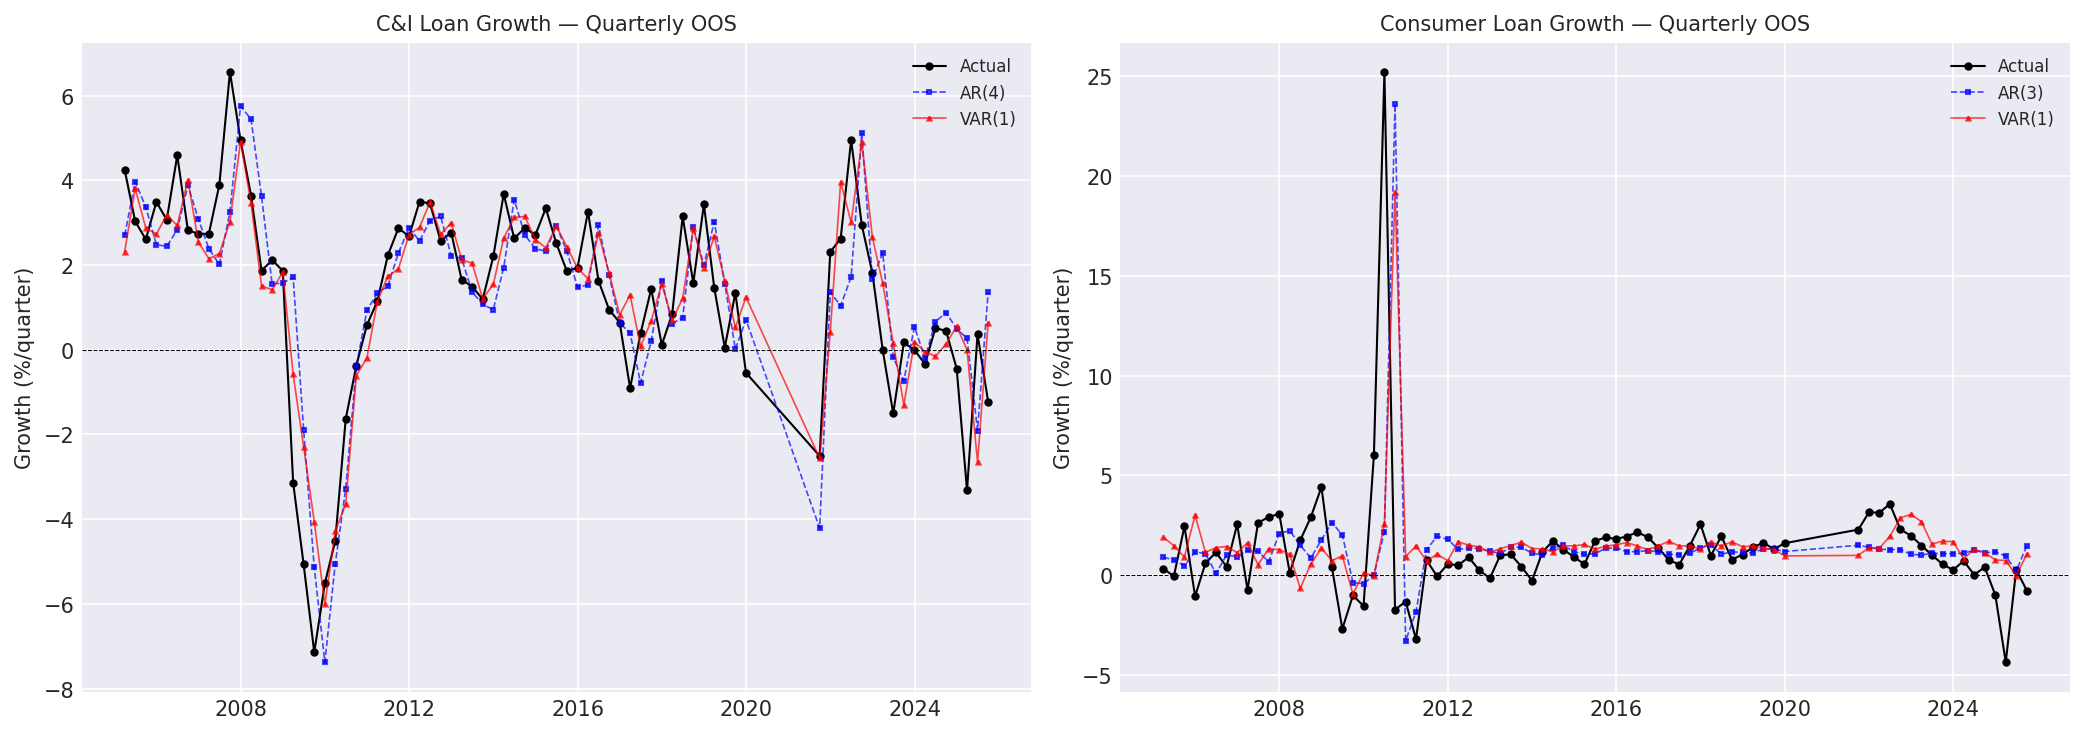

In [24]:
# OOS plot — use separate date arrays for AR and VAR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, ar_p, var_p, ar_dates, ar_act, ar_fc, var_dates, var_fc in [
    (axes[0], 'C&I Loan Growth',
     ar_bus_p_q, ci_p_q,
     dates_ci_q, act_ci_q, fc_ar_ci_q,
     dates_ci_var_q, fc_var_ci_q),
    (axes[1], 'Consumer Loan Growth',
     ar_con_p_q, con_p_q,
     dates_con_q, act_con_q, fc_ar_con_q,
     dates_con_var_q, fc_var_con_q),
]:
    ax.plot(ar_dates, ar_act, 'k-o', ms=3, lw=1, label='Actual')
    ax.plot(ar_dates, ar_fc, 'b--s', ms=2, lw=0.8, alpha=0.7, label=f'AR({ar_p})')
    ax.plot(var_dates, var_fc, 'r-^', ms=2, lw=0.8, alpha=0.7, label=f'VAR({var_p})')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{title} — Quarterly OOS', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Growth (%/quarter)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_oos_evaluation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()


## 8. Quarterly Scenario-Conditional Forecasts (2026-2050)

In [25]:
def conditional_var_forecast_q(var_result, endog_hist, ngfs_path,
                                target_col, forecast_dates, covid_val=0):
    """Quarterly conditional VAR forecast using NGFS macro paths."""
    p = var_result.k_ar
    k_trend = var_result.k_trend
    var_names = list(endog_hist.columns)
    target_idx = var_names.index(target_col)

    coefs = var_result.coefs
    intercept = var_result.intercept
    coefs_exog = var_result.coefs_exog
    coefs_user_exog = coefs_exog[:, k_trend:]

    history = endog_hist.values[-p:].copy()

    forecasts = []
    for date in forecast_dates:
        # Find closest NGFS date
        if date not in ngfs_path.index:
            # Find nearest available date
            diffs = abs(ngfs_path.index - date)
            nearest = ngfs_path.index[diffs.argmin()]
            if abs((nearest - date).days) > 120:  # more than ~1 quarter away
                break
            ngfs_row = ngfs_path.loc[nearest]
        else:
            ngfs_row = ngfs_path.loc[date]

        y_hat = intercept.copy()
        for lag in range(p):
            y_hat += coefs[lag] @ history[-(lag + 1)]

        exog_future = np.array([covid_val])
        y_hat += coefs_user_exog @ exog_future

        y_mixed = y_hat.copy()
        for i, var_name in enumerate(var_names):
            if var_name != target_col and var_name in ngfs_row.index:
                y_mixed[i] = ngfs_row[var_name]

        forecasts.append(y_mixed[target_idx])
        history = np.vstack([history, y_mixed.reshape(1, -1)])
        if len(history) > p:
            history = history[-p:]

    return pd.Series(forecasts, index=forecast_dates[:len(forecasts)], name=target_col)


# Generate quarterly forecast dates (2026 Q1 through 2050 Q4)
forecast_dates_q = pd.date_range(start='2026-03-31', end='2050-12-31', freq='QE')

ci_forecasts_q = {}
con_forecasts_q = {}

for (model, scenario), path in ngfs_q_paths.items():
    fc_ci = conditional_var_forecast_q(
        ci_var_q, ci_data_q, path,
        target_col='BUSLOANS_g', forecast_dates=forecast_dates_q)
    ci_forecasts_q[(model, scenario)] = fc_ci

    fc_con = conditional_var_forecast_q(
        con_var_q, con_data_q, path,
        target_col='CONSUMER_g', forecast_dates=forecast_dates_q)
    con_forecasts_q[(model, scenario)] = fc_con

print(f'Generated quarterly forecasts:')
print(f'  C&I:      {len(ci_forecasts_q)} paths')
print(f'  Consumer: {len(con_forecasts_q)} paths')

# Verify no NaN
for (m, s), fc in ci_forecasts_q.items():
    if fc.isna().any():
        print(f'  WARNING: NaN in C&I forecast for {m}/{s}')
for (m, s), fc in con_forecasts_q.items():
    if fc.isna().any():
        print(f'  WARNING: NaN in Consumer forecast for {m}/{s}')

# Show sample
print(f'\nSample C&I quarterly forecasts (2030 Q4):')
target_date = pd.Timestamp('2030-12-31')
for (model, scen), fc in sorted(ci_forecasts_q.items()):
    nearest = fc.index[abs(fc.index - target_date).argmin()]
    label = f'{model[:20]} / {KEY_SCENARIO_SHORT.get(scen, scen)}'
    print(f'  {label:40s} | {fc.loc[nearest]:+.3f}%/q')

Generated quarterly forecasts:
  C&I:      9 paths
  Consumer: 9 paths

Sample C&I quarterly forecasts (2030 Q4):
  GCAM 6.0 NGFS / Delayed Trans.           | +0.510%/q
  GCAM 6.0 NGFS / NDCs                     | +0.546%/q
  GCAM 6.0 NGFS / Net Zero                 | +0.582%/q
  MESSAGEix-GLOBIOM 2. / Delayed Trans.    | +0.504%/q
  MESSAGEix-GLOBIOM 2. / NDCs              | +0.531%/q
  MESSAGEix-GLOBIOM 2. / Net Zero          | +0.806%/q
  REMIND-MAgPIE 3.3-4. / Delayed Trans.    | +0.513%/q
  REMIND-MAgPIE 3.3-4. / NDCs              | +0.614%/q
  REMIND-MAgPIE 3.3-4. / Net Zero          | +0.758%/q


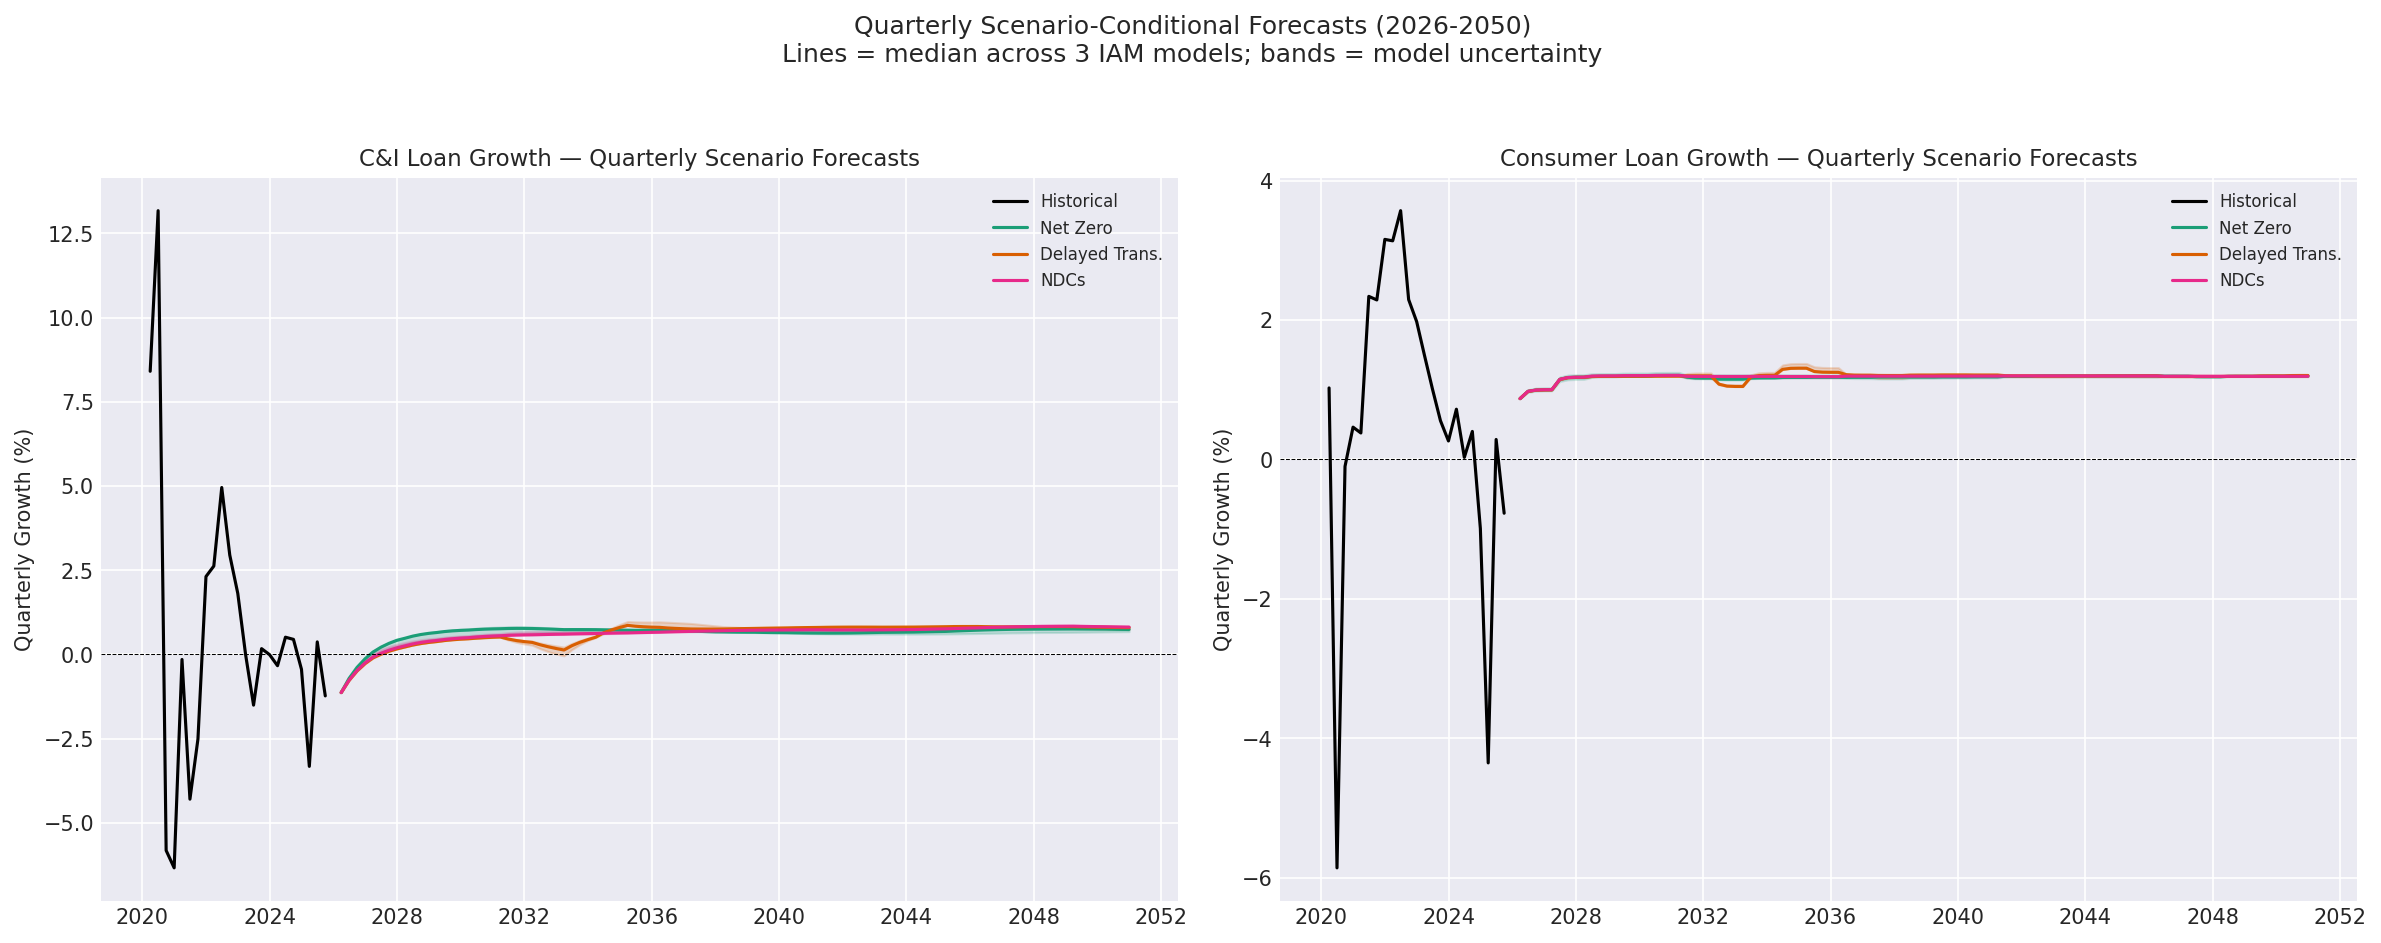

In [26]:
# Fan charts (quarterly)
def plot_fan_chart_q(forecasts, historical, title, ax, key_scenarios, scenario_colors,
                      scenario_short):
    ax.plot(historical.index, historical.values, 'k-', lw=1.5, label='Historical')

    for scen in key_scenarios:
        paths = [fc for (m, s), fc in forecasts.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo = paths_df.min(axis=1)
        hi = paths_df.max(axis=1)

        color = scenario_colors.get(scen, 'gray')
        label = scenario_short.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.2, color=color)

    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Quarterly Growth (%)')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hist_ci_q = quarterly.loc['2020-01-01':, 'BUSLOANS_g']
hist_con_q = quarterly.loc['2020-01-01':, 'CONSUMER_g']

plot_fan_chart_q(ci_forecasts_q, hist_ci_q,
                 'C&I Loan Growth — Quarterly Scenario Forecasts',
                 axes[0], KEY_SCENARIOS, SCENARIO_COLORS, KEY_SCENARIO_SHORT)
plot_fan_chart_q(con_forecasts_q, hist_con_q,
                 'Consumer Loan Growth — Quarterly Scenario Forecasts',
                 axes[1], KEY_SCENARIOS, SCENARIO_COLORS, KEY_SCENARIO_SHORT)

fig.suptitle('Quarterly Scenario-Conditional Forecasts (2026-2050)\n'
             'Lines = median across 3 IAM models; bands = model uncertainty',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_scenario_fan_charts.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 9. Cumulative Impact (Quarterly)

In [27]:
def cumulative_impact_q(forecasts, base_level=100, key_scenarios=None):
    cumul = {}
    for (model, scen), fc in forecasts.items():
        if key_scenarios and scen not in key_scenarios:
            continue
        levels = [base_level]
        for g in fc.values:
            levels.append(levels[-1] * np.exp(g / 100))
        level_series = pd.Series(levels[1:], index=fc.index)
        cumul[(model, scen)] = level_series
    return cumul

ci_cumul_q = cumulative_impact_q(ci_forecasts_q, key_scenarios=KEY_SCENARIOS)
con_cumul_q = cumulative_impact_q(con_forecasts_q, key_scenarios=KEY_SCENARIOS)

print('Cumulative Loan Balance Index — QUARTERLY MODEL (2025 = 100)')
print('=' * 70)

for loan_type, cumul_dict in [('C&I', ci_cumul_q), ('Consumer', con_cumul_q)]:
    print(f'\n--- {loan_type} Loans ---')
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        # Get values near year-end for comparison
        for year in [2030, 2040, 2050]:
            target = pd.Timestamp(f'{year}-12-31')
            nearest = paths_df.index[abs(paths_df.index - target).argmin()]
            med = paths_df.loc[nearest].median()
            lo = paths_df.loc[nearest].min()
            hi = paths_df.loc[nearest].max()
            if year == 2030:
                print(f'  {KEY_SCENARIO_SHORT.get(scen, scen):18s} | ', end='')
            else:
                print(f'  {"":18s} | ', end='')
            print(f'{year}: {med:6.1f} [{lo:.1f}-{hi:.1f}]')

Cumulative Loan Balance Index — QUARTERLY MODEL (2025 = 100)

--- C&I Loans ---
  Net Zero           | 2030:  107.0 [103.7-107.2]
                     | 2040:  141.9 [136.9-142.6]
                     | 2050:  185.3 [182.5-189.0]
  Delayed Trans.     | 2030:  102.3 [102.3-102.4]
                     | 2040:  132.5 [132.0-133.8]
                     | 2050:  183.3 [182.5-185.0]
  NDCs               | 2030:  102.9 [102.9-104.5]
                     | 2040:  133.6 [133.6-138.3]
                     | 2050:  183.7 [182.8-187.2]

--- Consumer Loans ---
  Net Zero           | 2030:  125.4 [125.1-126.3]
                     | 2040:  202.0 [199.4-203.2]
                     | 2050:  325.5 [320.7-328.2]
  Delayed Trans.     | 2030:  125.4 [125.4-125.4]
                     | 2040:  203.2 [202.9-203.7]
                     | 2050:  327.9 [327.4-328.4]
  NDCs               | 2030:  125.6 [125.5-125.6]
                     | 2040:  202.2 [201.1-202.4]
                     | 2050:  326.4 [323.8-326

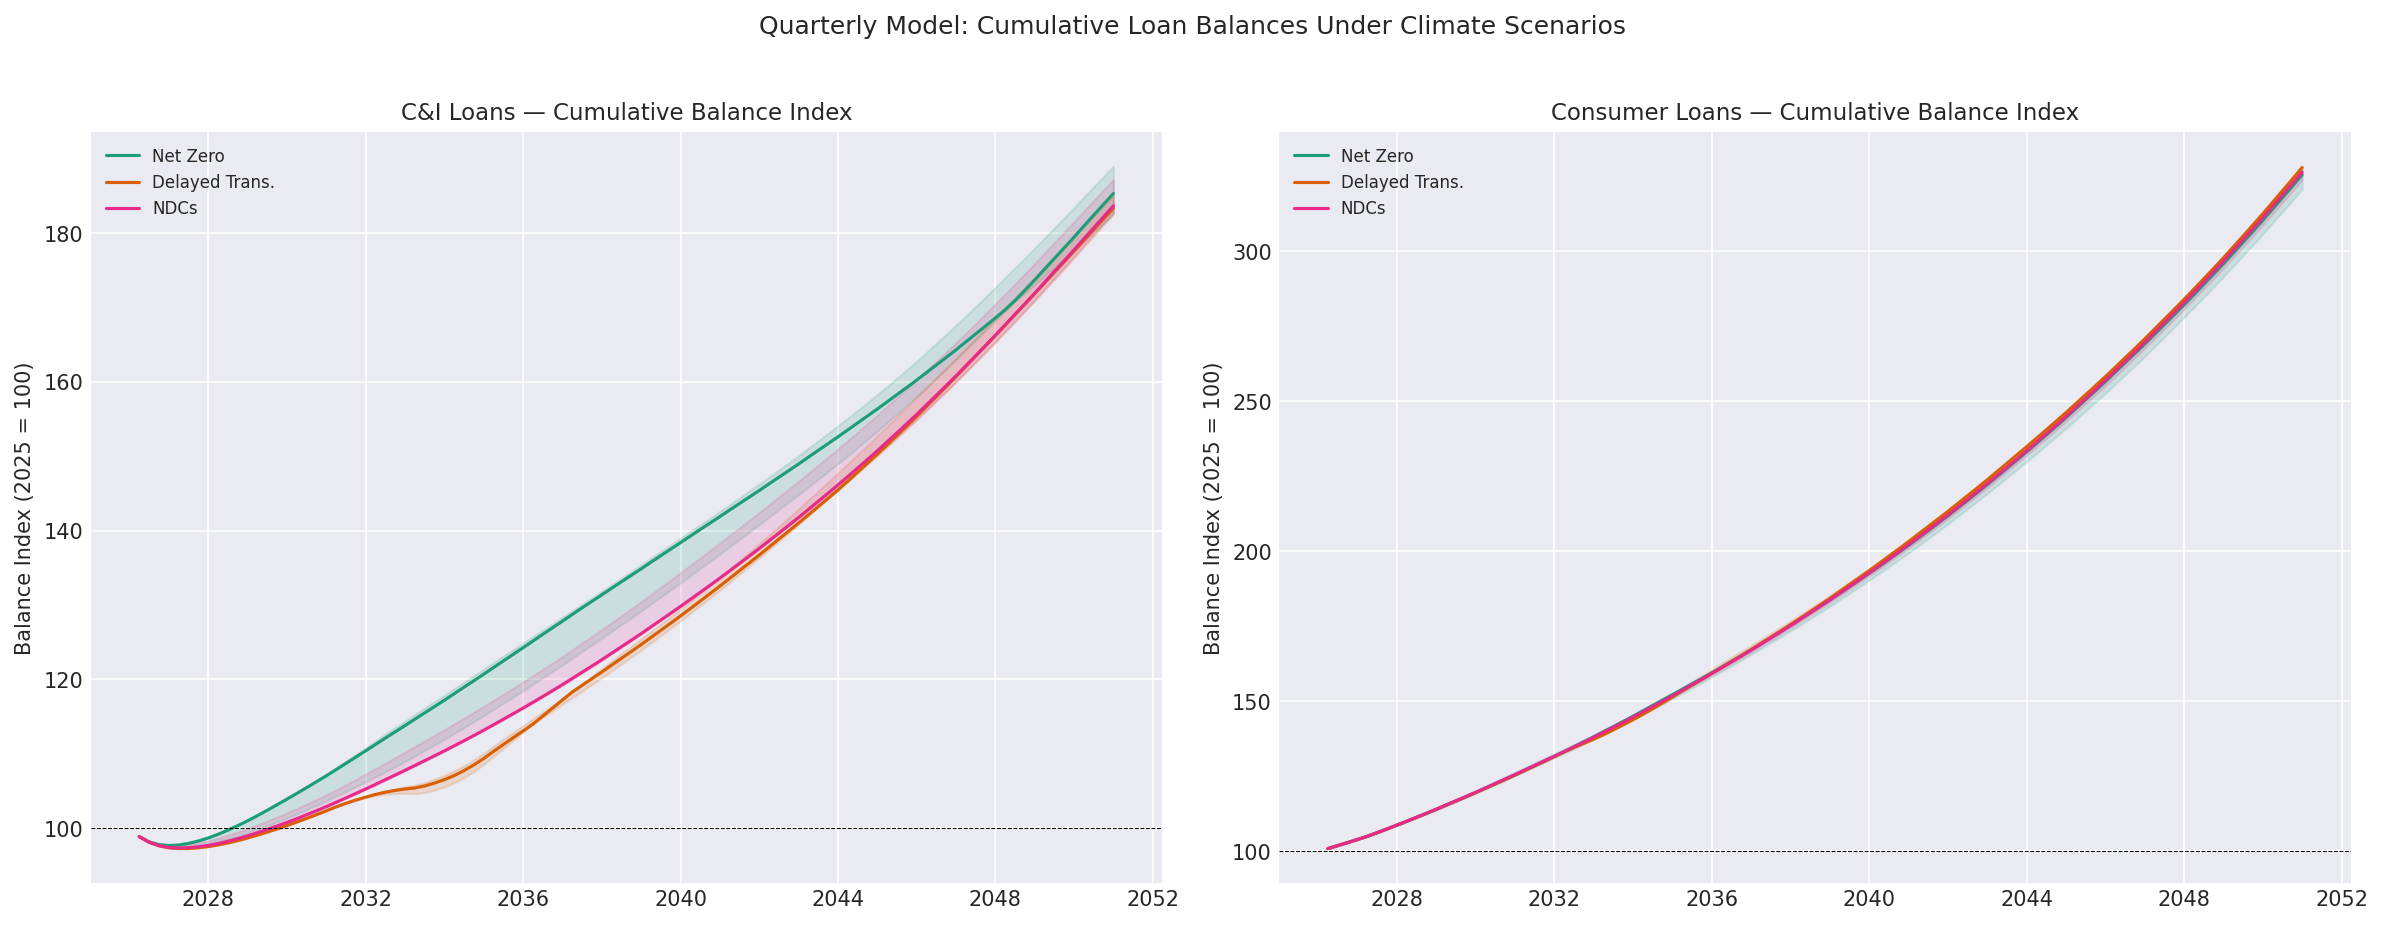

In [28]:
# Cumulative impact plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cumul_dict, title in [
    (axes[0], ci_cumul_q, 'C&I Loans — Cumulative Balance Index'),
    (axes[1], con_cumul_q, 'Consumer Loans — Cumulative Balance Index'),
]:
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo = paths_df.min(axis=1)
        hi = paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        label = KEY_SCENARIO_SHORT.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.15, color=color)

    ax.axhline(100, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Balance Index (2025 = 100)')
    ax.legend(fontsize=8)

fig.suptitle('Quarterly Model: Cumulative Loan Balances Under Climate Scenarios',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}quarterly_cumulative_impact.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 10. Annual vs Quarterly Comparison Summary

In [29]:
print('=' * 80)
print('ANNUAL vs QUARTERLY MODEL COMPARISON')
print('=' * 80)

print(f'\n{"DIMENSION":30s} {"ANNUAL":>20s} {"QUARTERLY":>20s}')
print('-' * 70)
print(f'{"Observations":30s} {"36":>20s} {len(ci_data_q):>20d}')
print(f'{"C&I VAR order":30s} {"VAR(1)":>20s} {"VAR(" + str(ci_p_q) + ")":>20s}')
print(f'{"Consumer VAR order":30s} {"VAR(1)":>20s} {"VAR(" + str(con_p_q) + ")":>20s}')

ar_ci_str = f'{rmse_ar_ci_q:.2f}' if not np.isnan(rmse_ar_ci_q) else 'N/A'
ar_con_str = f'{rmse_ar_con_q:.2f}' if not np.isnan(rmse_ar_con_q) else 'N/A'

print(f'{"C&I AR baseline RMSE":30s} {10.09:>20.2f} {ar_ci_str:>20s}')
print(f'{"C&I VAR RMSE":30s} {9.05:>20.2f} {rmse_var_ci_q:>20.2f}')
if not np.isnan(rmse_ar_ci_q) and rmse_ar_ci_q > 0:
    print(f'{"C&I VAR vs AR":30s} {"10.4%":>20s} {f"{(1-rmse_var_ci_q/rmse_ar_ci_q)*100:.1f}%":>20s}')
print(f'{"Consumer AR baseline RMSE":30s} {16.85:>20.2f} {ar_con_str:>20s}')
print(f'{"Consumer VAR RMSE":30s} {14.03:>20.2f} {rmse_var_con_q:>20.2f}')
if not np.isnan(rmse_ar_con_q) and rmse_ar_con_q > 0:
    print(f'{"Consumer VAR vs AR":30s} {"16.7%":>20s} {f"{(1-rmse_var_con_q/rmse_ar_con_q)*100:.1f}%":>20s}')

print(f'\nGranger Causality — KEY COMPARISON:')
print(f'  Unemployment -> Consumer loans:')
print(f'    Annual:    p = 0.81 (NOT significant)')
print(f'    Quarterly: see Granger results above')
print(f'  DGS10 -> Consumer loans:')
print(f'    Annual:    p = 0.023 (significant)')
print(f'    Quarterly: see Granger results above')


ANNUAL vs QUARTERLY MODEL COMPARISON

DIMENSION                                    ANNUAL            QUARTERLY
----------------------------------------------------------------------
Observations                                     36                  143
C&I VAR order                                VAR(1)               VAR(1)
Consumer VAR order                           VAR(1)               VAR(1)
C&I AR baseline RMSE                          10.09                 1.49
C&I VAR RMSE                                   9.05                 1.32
C&I VAR vs AR                                 10.4%                11.7%
Consumer AR baseline RMSE                     16.85                 4.20
Consumer VAR RMSE                             14.03                 3.89
Consumer VAR vs AR                            16.7%                 7.5%

Granger Causality — KEY COMPARISON:
  Unemployment -> Consumer loans:
    Annual:    p = 0.81 (NOT significant)
    Quarterly: see Granger results above
  DGS10

In [30]:
# Final diagnostics
print('=' * 70)
print('QUARTERLY MODEL DIAGNOSTICS SUMMARY')
print('=' * 70)

for name, var_result, target in [
    ('C&I', ci_var_q, 'BUSLOANS_g'),
    ('Consumer', con_var_q, 'CONSUMER_g')
]:
    resid = var_result.resid[target]
    lb = acorr_ljungbox(resid, lags=[4, 8, 12], return_df=True)
    adf = adfuller(resid)
    print(f'\n{name} VAR({var_result.k_ar}):')
    print(f'  Observations: {var_result.nobs}')
    print(f'  Ljung-Box: lag4 p={lb["lb_pvalue"].iloc[0]:.3f}, '
          f'lag8 p={lb["lb_pvalue"].iloc[1]:.3f}, lag12 p={lb["lb_pvalue"].iloc[2]:.3f}')
    print(f'  ADF on residuals: p={adf[1]:.4f}')
    print(f'  Residual std: {resid.std():.3f}')
    # Check stability
    roots = np.abs(np.linalg.eigvals(np.array(var_result.coefs).reshape(-1, len(var_result.coefs[0]))))
    print(f'  Max eigenvalue modulus: {roots.max():.4f} (stable if < 1)')

print(f'\nForecasts generated: {len(ci_forecasts_q)} C&I + {len(con_forecasts_q)} Consumer')

# Check for any NaN
nan_count = sum(fc.isna().sum() for fc in ci_forecasts_q.values())
nan_count += sum(fc.isna().sum() for fc in con_forecasts_q.values())
print(f'NaN values in forecasts: {nan_count}')
print(f'\nAll figures saved to {FIG_DIR}')

QUARTERLY MODEL DIAGNOSTICS SUMMARY

C&I VAR(1):
  Observations: 142
  Ljung-Box: lag4 p=0.047, lag8 p=0.166, lag12 p=0.300
  ADF on residuals: p=0.0000
  Residual std: 1.765
  Max eigenvalue modulus: 0.7366 (stable if < 1)

Consumer VAR(1):
  Observations: 142
  Ljung-Box: lag4 p=0.457, lag8 p=0.660, lag12 p=0.854
  ADF on residuals: p=0.0000
  Residual std: 2.554
  Max eigenvalue modulus: 0.5885 (stable if < 1)

Forecasts generated: 9 C&I + 9 Consumer
NaN values in forecasts: 0

All figures saved to outputs/figures/
